In [9]:
import time
import datetime as dt
import numpy as np
import pandas as pd
from rivapy.optimization.models.batterystorage import BatteryStorage
from rivapy.marketdata import EnergyPriceForwardCurve
import matplotlib.pyplot as plt

In [13]:
eff_in = 0.97
eff_out = 0.97
np.random.seed(25)
states = np.arange(0, 100.5, step=0.5, dtype=np.float32)
actions = np.arange(-25, 26)

timesteps = 1000

prices = np.random.uniform(low=1, high=10, size=timesteps).astype(np.float32)
max_charges = 20
max_capacity = 100.0

dates = [dt.datetime(2024, 1, 1) + dt.timedelta(days=i) for i in range(timesteps)]
pfc = EnergyPriceForwardCurve.from_existing_pfc(id="1", pfc=pd.DataFrame(data=prices, index=dates), refdate=dt.datetime.today())


batterystorage = BatteryStorage(
    eff_in=eff_in, eff_out=eff_out, max_capacity=max_capacity, pfc=pfc, max_charges=max_charges, states=states, actions=actions, precompile=False
)

In [14]:
start = time.time()
batterystorage.optimize()
end = time.time()
print(end - start)


6.320221424102783


In [15]:
batterystorage_output = batterystorage.create_output()
batterystorage_output

2623.1388397216797


,DateTime,Price,SOC,ChargeCycle,Charging,Value
0,2024-01-01,8.831118,100.0,0,0.0,-0.0
1,2024-01-02,6.240492,100.0,0,0.0,-0.0
2,2024-01-03,3.509551,100.0,0,0.0,-0.0
3,2024-01-04,2.673201,100.0,0,0.0,-0.0
4,2024-01-05,4.699901,100.0,0,0.0,-0.0
...,...,...,...,...,...,...
995,2026-09-22,6.553982,0.0,20,0.0,0.0
996,2026-09-23,6.508981,0.0,20,0.0,0.0
997,2026-09-24,3.548200,0.0,20,0.0,0.0
998,2026-09-25,5.574974,0.0,20,0.0,0.0


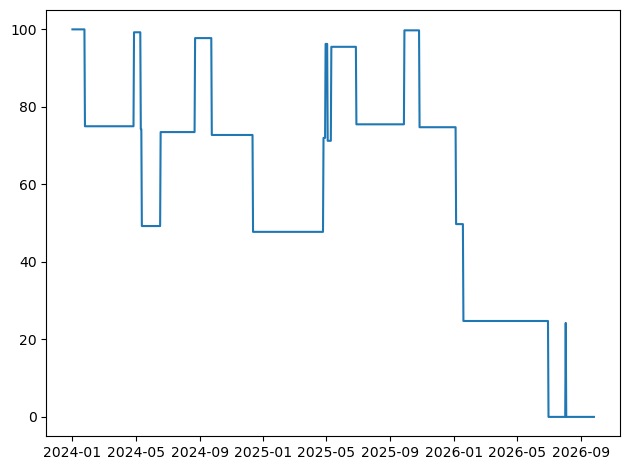

In [16]:
plt.plot(batterystorage_output['DateTime'], batterystorage_output['SOC'])
plt.tight_layout()

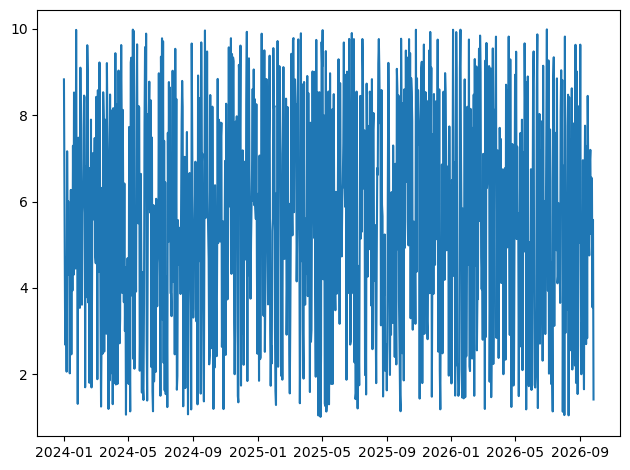

In [12]:
plt.plot(batterystorage_output['DateTime'], batterystorage_output['Price'])
plt.tight_layout()